import libraries

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load dataset

In [178]:
df=pd.read_csv("/content/restaurant_sales.csv")

quick review

In [179]:
print(df.head(5))

         date   sales
0  2025-01-01  281.64
1  2025-01-02  212.74
2  2025-01-03  250.61
3  2025-01-04  253.38
4  2025-01-05  253.00


In [180]:
print(df.shape)

(365, 2)


In [181]:
print(df.describe())

            sales
count  365.000000
mean   249.464795
std     40.075500
min    176.270000
25%    218.560000
50%    245.370000
75%    279.870000
max    419.330000


In [182]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    365 non-null    object 
 1   sales   365 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB
None


Time-series check

In [183]:
if df.index.name == 'date':
    df.reset_index(inplace=True)
df['date']=pd.to_datetime(df['date'],format='%Y-%m-%d')

In [184]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    365 non-null    datetime64[ns]
 1   sales   365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB
None


In [185]:
df.isnull().sum().sum()

0

In [186]:
df.duplicated().sum()

0

In [187]:
df.index

RangeIndex(start=0, stop=365, step=1)

In [188]:
df.index=df['date']

In [189]:
df.head(5)

,date,sales
date,,
2025-01-01,2025-01-01,281.64
2025-01-02,2025-01-02,212.74
2025-01-03,2025-01-03,250.61
2025-01-04,2025-01-04,253.38
2025-01-05,2025-01-05,253.00


In [190]:
del df['date']

In [191]:
df.head(5)

,sales
date,
2025-01-01,281.64
2025-01-02,212.74
2025-01-03,250.61
2025-01-04,253.38
2025-01-05,253.00


In [192]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2025-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   365 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB
None


plot sales trend

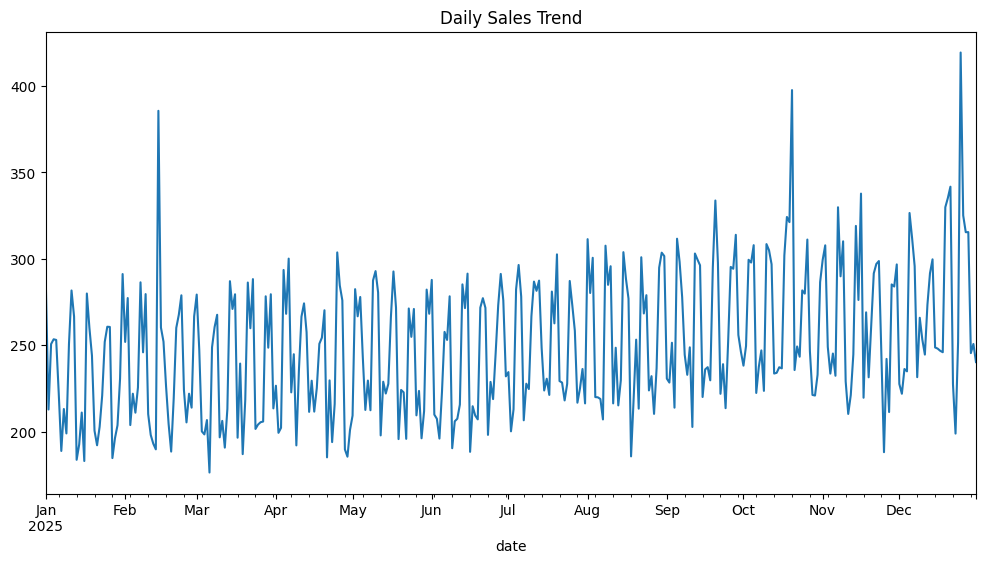

In [193]:
plt.figure(figsize=(12,6))
df['sales'].plot(title="Daily Sales Trend")
plt.show()

Seasonality check

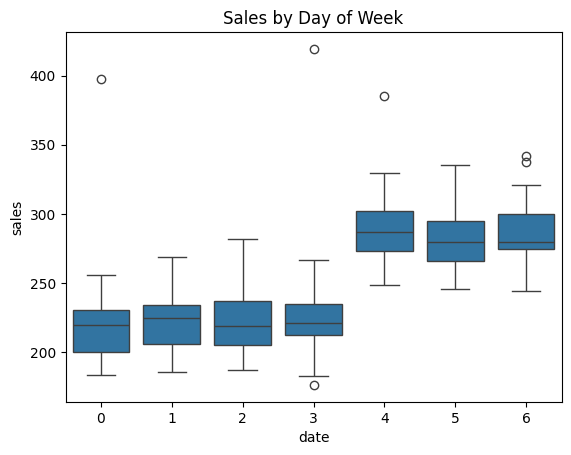

In [194]:
sns.boxplot(x=df.index.dayofweek, y=df['sales'])
plt.title("Sales by Day of Week")
plt.show()


In [195]:
from statsmodels.tsa.stattools import adfuller

In [196]:
result=adfuller(df['sales'])

In [197]:
print(result[1])

0.805321277897197


In [198]:
p_value=result[1]

In [199]:
if p_value < 0.05:
  print("accepted as stationary")
else:
  print("rejected as non stationary")

rejected as non stationary


non-stationary so doing differencing

In [200]:
rolling_mean=df['sales'].rolling(window=12).mean()

In [201]:
df_new=df['sales']-rolling_mean

In [202]:
df_new.head(15)

,sales
date,
2025-01-01,NaN
2025-01-02,NaN
2025-01-03,NaN
2025-01-04,NaN
2025-01-05,NaN
2025-01-06,NaN
2025-01-07,NaN
2025-01-08,NaN
2025-01-09,NaN


on 12th moving avg starts

<Axes: title={'center': 'differenced data'}, xlabel='date'>

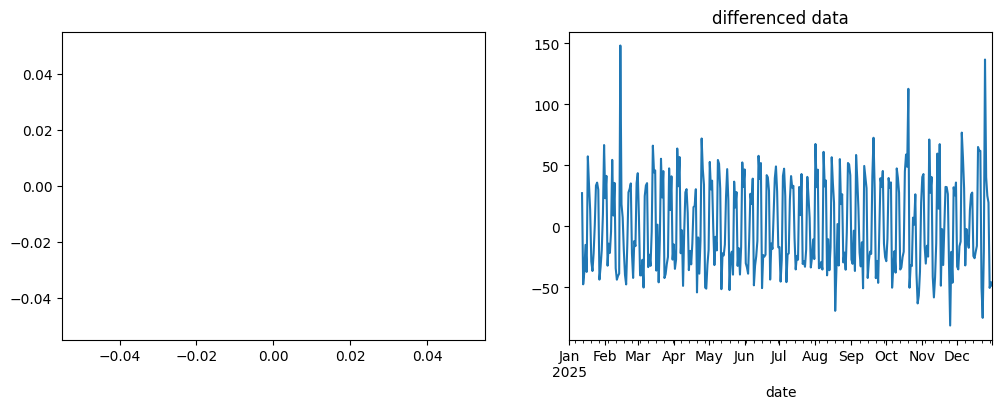

In [203]:
ax1=plt.subplot(1,2,1)
ax1.plot(figsize=(12,4),color='tab:red',title ='original data',ax=ax1)
ax2=plt.subplot(1,2,2)
df_new.plot(figsize=(12,4),color='tab:blue',title='differenced data',ax=ax2)

In [204]:
m=df_new.rolling(window=12).mean()
s=df_new.rolling(window=12).std()

In [205]:
print(m)

date
2025-01-01          NaN
2025-01-02          NaN
2025-01-03          NaN
2025-01-04          NaN
2025-01-05          NaN
                ...    
2025-12-27    15.093056
2025-12-28    18.892708
2025-12-29    16.417778
2025-12-30    13.961042
2025-12-31     4.495417
Name: sales, Length: 365, dtype: float64


In [206]:
print(s)

date
2025-01-01          NaN
2025-01-02          NaN
2025-01-03          NaN
2025-01-04          NaN
2025-01-05          NaN
                ...    
2025-12-27    60.282205
2025-12-28    58.861888
2025-12-29    61.259940
2025-12-30    63.244093
2025-12-31    63.422271
Name: sales, Length: 365, dtype: float64


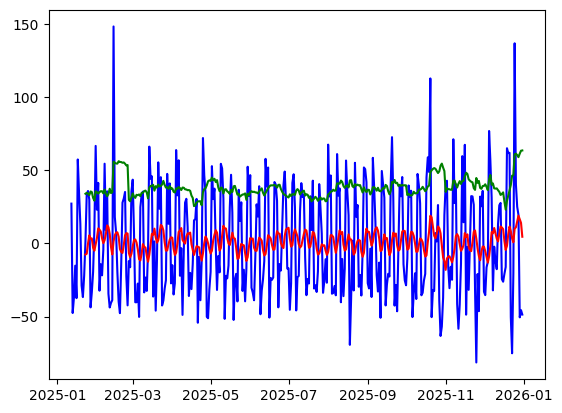

In [207]:
plt.plot(df_new,color='blue')
plt.plot(m,color='red')
plt.plot(s,color='green')
plt.show()

In [208]:
df_new.dropna(inplace=True)

In [209]:
print(df_new.head(15))

date
2025-01-12    27.114167
2025-01-13   -47.598333
2025-01-14   -37.032500
2025-01-15   -15.269167
2025-01-16   -37.438333
2025-01-17    57.262500
2025-01-18    34.253333
2025-01-19    13.527500
2025-01-20   -28.865000
2025-01-21   -36.705000
2025-01-22   -22.074167
2025-01-23     1.122500
2025-01-24    33.365000
2025-01-25    35.747500
2025-01-26    29.960000
Name: sales, dtype: float64


In [210]:
result=adfuller(df_new)
p_value=result[1]
if p_value < 0.05:
  print("accepted as stationary")
else:
  print("rejected as non stationary")

accepted as stationary


splitting of data manually

In [211]:
print(df_new.shape)

(354,)


In [212]:
train=df_new[:330]
train.shape
test=df_new[330:]
test.shape

(24,)

In [213]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train,order=(1,0,1))
model_fit=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


<Axes: >

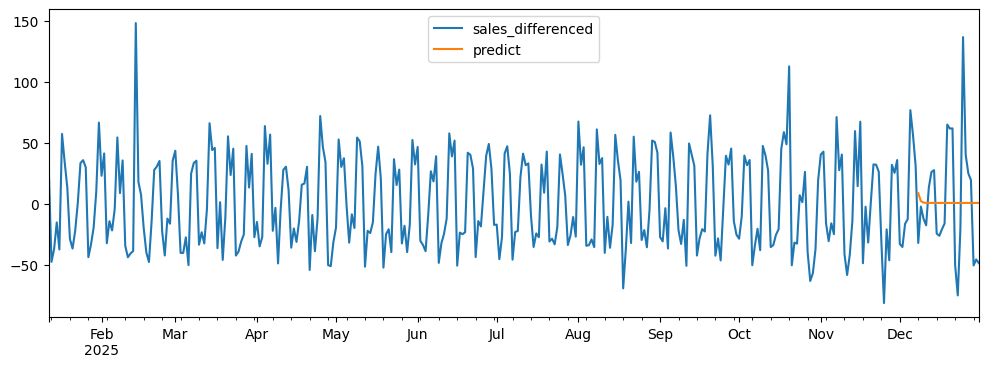

In [214]:
predictions = model_fit.predict(start=len(train),end=len(train)+len(test)-1,typ='levels')
plot_df = pd.DataFrame({'sales_differenced': df_new, 'predict': predictions})
plot_df[['sales_differenced','predict']].plot(figsize=(12,4))

In [215]:
!pip install numpy==1.26.4

In [216]:
!pip install pmdarima

In [217]:
from pmdarima import auto_arima

In [218]:
import numpy as np
import pandas as pd

# Ensure df_new is numeric, coercing any non-numeric values to NaN
df_new_numeric = pd.to_numeric(df_new, errors='coerce')
# Drop any NaNs that resulted from coercion or were already present
data_for_arima = df_new_numeric.dropna().values

auto=auto_arima(data_for_arima)
auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  354
Model:               SARIMAX(4, 0, 0)   Log Likelihood               -1657.864
Date:                Mon, 18 May 2026   AIC                           3325.729
Time:                        04:34:50   BIC                           3345.075
Sample:                             0   HQIC                          3333.426
                                - 354                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0041      0.052      0.079      0.937      -0.097       0.105
ar.L2          0.0101      0.045      0.224      0.823      -0.078       0.098
ar.L3         -0.4635      0.039    -11.817      0.000      -0.540      -0.387
ar.L4         -0.4360      0.042    -10.443      0.000      -0.518      -0.354
sigma2       680.1130     31.229     21.778      0.000     618.905     741.321
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):               216.40
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               1.70   Skew:                             0.71
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

according to auto arima MODEL : SARIMAX(4,0,0)

In [219]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [220]:
model1=SARIMAX(train,order=(4,0,0),seasonal_order=(3,0,2,12))
model_fit1=model1.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [221]:
df_new['sales']=model_fit1.predict(start=len(train),end=len(train)+len(test)-1)

<Axes: >

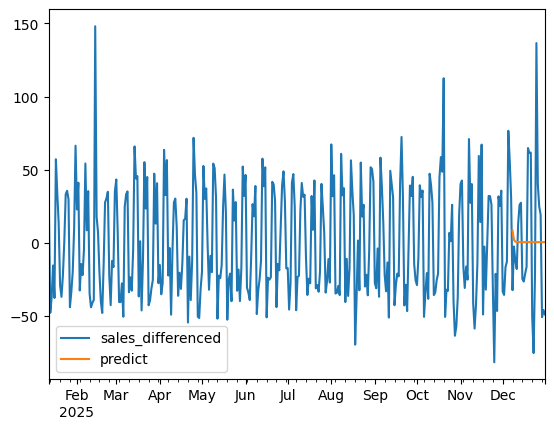

In [222]:
plot_df[['sales_differenced','predict']].plot()

forecasting

In [223]:
forcasted=model_fit1.forecast(steps=12)

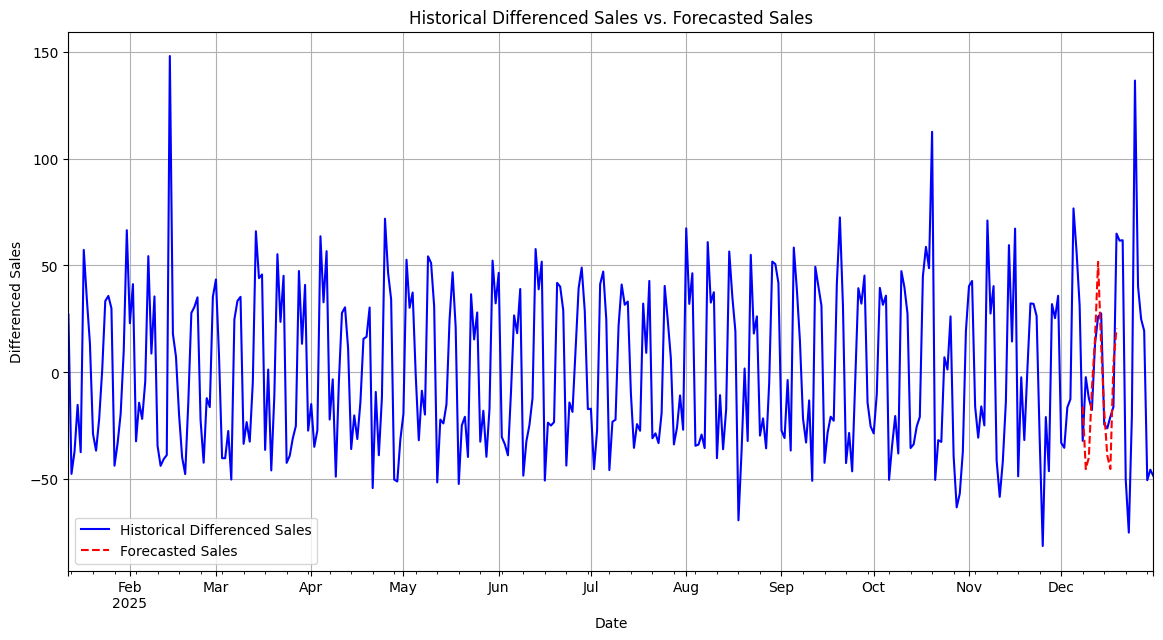

In [224]:
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Plot historical differenced sales
plot_df['sales_differenced'].plot(ax=ax, label='Historical Differenced Sales', color='blue')

# Plot forecasted values
forcasted.plot(ax=ax, label='Forecasted Sales', color='red', linestyle='--')

plt.title('Historical Differenced Sales vs. Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Differenced Sales')
plt.legend()
plt.grid(True)
plt.show()

Lag features

In [225]:

df['lag_7'] = df['sales'].shift(7)
df['lag_30'] = df['sales'].shift(30)


In [226]:
print(df['lag_7'])

date
2025-01-01       NaN
2025-01-02       NaN
2025-01-03       NaN
2025-01-04       NaN
2025-01-05       NaN
               ...  
2025-12-27    335.16
2025-12-28    341.68
2025-12-29    227.39
2025-12-30    198.80
2025-12-31    251.66
Name: lag_7, Length: 365, dtype: float64


In [227]:
print(df['lag_30'])

date
2025-01-01       NaN
2025-01-02       NaN
2025-01-03       NaN
2025-01-04       NaN
2025-01-05       NaN
               ...  
2025-12-27    211.27
2025-12-28    285.13
2025-12-29    283.91
2025-12-30    296.70
2025-12-31    227.51
Name: lag_30, Length: 365, dtype: float64


 Rolling averages

In [228]:
df['rolling_7'] = df['sales'].rolling(7).mean()
df['rolling_14'] = df['sales'].rolling(14).mean()

In [229]:
print(df['rolling_7'])

date
2025-01-01           NaN
2025-01-02           NaN
2025-01-03           NaN
2025-01-04           NaN
2025-01-05           NaN
                 ...    
2025-12-27    297.040000
2025-12-28    293.285714
2025-12-29    295.854286
2025-12-30    303.264286
2025-12-31    301.624286
Name: rolling_7, Length: 365, dtype: float64


In [230]:
print(df['rolling_14'])

date
2025-01-01           NaN
2025-01-02           NaN
2025-01-03           NaN
2025-01-04           NaN
2025-01-05           NaN
                 ...    
2025-12-27    288.080714
2025-12-28    289.206429
2025-12-29    288.972143
2025-12-30    289.164286
2025-12-31    288.697857
Name: rolling_14, Length: 365, dtype: float64


 Date-based features

In [231]:
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [232]:
print(df['day_of_week'])

date
2025-01-01    2
2025-01-02    3
2025-01-03    4
2025-01-04    5
2025-01-05    6
             ..
2025-12-27    5
2025-12-28    6
2025-12-29    0
2025-12-30    1
2025-12-31    2
Name: day_of_week, Length: 365, dtype: int32


In [233]:
print(df['month'])

date
2025-01-01     1
2025-01-02     1
2025-01-03     1
2025-01-04     1
2025-01-05     1
              ..
2025-12-27    12
2025-12-28    12
2025-12-29    12
2025-12-30    12
2025-12-31    12
Name: month, Length: 365, dtype: int32


In [234]:
print(df['is_weekend'])

date
2025-01-01    0
2025-01-02    0
2025-01-03    0
2025-01-04    1
2025-01-05    1
             ..
2025-12-27    1
2025-12-28    1
2025-12-29    0
2025-12-30    0
2025-12-31    0
Name: is_weekend, Length: 365, dtype: int64


External signals (temperature, rainfall, local events)

Merge weather data

In [235]:
weather = pd.read_csv("/content/Daily_Weather_Insights.csv")


In [236]:
print(weather.head(5))

         Date   City  Temperature_High (°C)  Temperature_Low (°C)  \
0  2025-01-01  Cairo                   16.9                  14.1   
1  2025-01-02  Cairo                   15.1                   5.6   
2  2025-01-03  Cairo                   25.1                  18.2   
3  2025-01-04  Cairo                   28.9                   9.9   
4  2025-01-05  Cairo                   17.6                  13.7   

   Humidity (%)  Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
0          43.1               24.2             Sunny                145   
1          56.9                8.2             Windy                115   
2          52.5               18.2             Snowy                 11   
3          76.3               18.8             Rainy                 22   
4          55.6               10.8             Sunny                 39   

   Precipitation (mm)  Visibility (km)  
0                17.2              4.7  
1                 0.5              9.8  
2          

In [237]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   90 non-null     object 
 1   City                   90 non-null     object 
 2   Temperature_High (°C)  90 non-null     float64
 3   Temperature_Low (°C)   90 non-null     float64
 4   Humidity (%)           90 non-null     float64
 5   Wind_Speed (km/h)      90 non-null     float64
 6   Weather_Condition      90 non-null     object 
 7   Air_Quality_Index      90 non-null     int64  
 8   Precipitation (mm)     90 non-null     float64
 9   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(3)
memory usage: 7.2+ KB
None


In [238]:
print(weather.describe())

       Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
count              90.000000             90.000000     90.000000   
mean               25.588889             12.632222     52.785556   
std                 5.648614              4.077393     14.935694   
min                15.100000              5.200000     30.300000   
25%                20.625000              9.100000     41.025000   
50%                26.800000             12.500000     49.550000   
75%                29.575000             16.075000     64.475000   
max                34.900000             19.800000     78.100000   

       Wind_Speed (km/h)  Air_Quality_Index  Precipitation (mm)  \
count          90.000000          90.000000           90.000000   
mean           14.178889         105.300000            9.557778   
std             5.677780          56.111736            6.048326   
min             5.100000          11.000000            0.400000   
25%             9.575000          59.000000         

In [239]:
print(weather.isnull().sum())

Date                     0
City                     0
Temperature_High (°C)    0
Temperature_Low (°C)     0
Humidity (%)             0
Wind_Speed (km/h)        0
Weather_Condition        0
Air_Quality_Index        0
Precipitation (mm)       0
Visibility (km)          0
dtype: int64


In [240]:
print(weather.duplicated().sum())

0


In [241]:
print(weather.shape)

(90, 10)


In [242]:
# Reload the weather DataFrame to ensure 'Date' column is present in its original form
#weather = pd.read_csv("/content/Daily_Weather_Insights.csv")

# Convert 'Date' column to datetime, specifying format and coercing errors to NaT
weather['Date'] = pd.to_datetime(weather['Date'], format='%Y-%m-%d', errors='coerce')

# Drop any rows where the 'Date' conversion resulted in NaT
weather.dropna(subset=['Date'], inplace=True)

# Set 'Date' as the index. `drop=True` by default will remove the column.
weather.set_index('Date', inplace=True)

In [243]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   90 non-null     object 
 1   Temperature_High (°C)  90 non-null     float64
 2   Temperature_Low (°C)   90 non-null     float64
 3   Humidity (%)           90 non-null     float64
 4   Wind_Speed (km/h)      90 non-null     float64
 5   Weather_Condition      90 non-null     object 
 6   Air_Quality_Index      90 non-null     int64  
 7   Precipitation (mm)     90 non-null     float64
 8   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 7.0+ KB
None


In [244]:
print(weather.head(5))

             City  Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
Date                                                                           
2025-01-01  Cairo                   16.9                  14.1          43.1   
2025-01-02  Cairo                   15.1                   5.6          56.9   
2025-01-03  Cairo                   25.1                  18.2          52.5   
2025-01-04  Cairo                   28.9                   9.9          76.3   
2025-01-05  Cairo                   17.6                  13.7          55.6   

            Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
Date                                                                 
2025-01-01               24.2             Sunny                145   
2025-01-02                8.2             Windy                115   
2025-01-03               18.2             Snowy                 11   
2025-01-04               18.8             Rainy                 22   
2025-01-05         

to check outliers

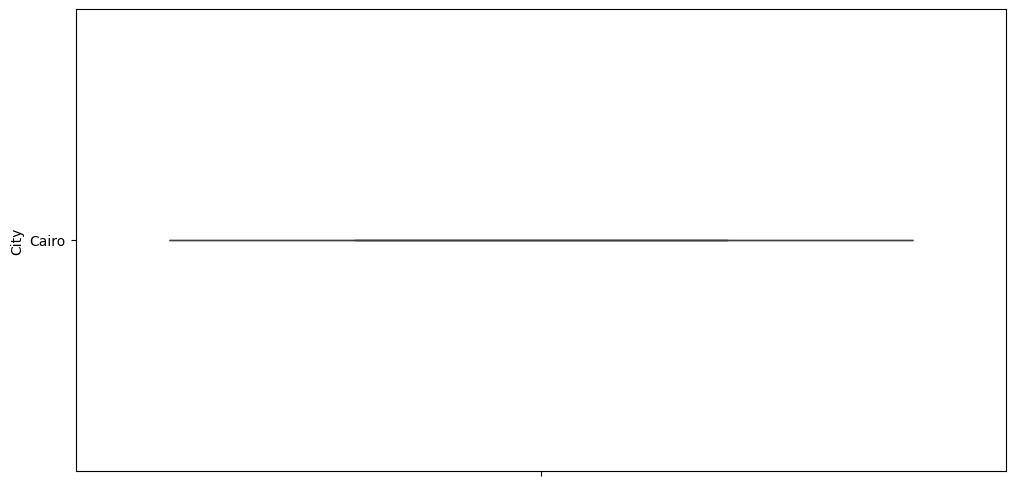

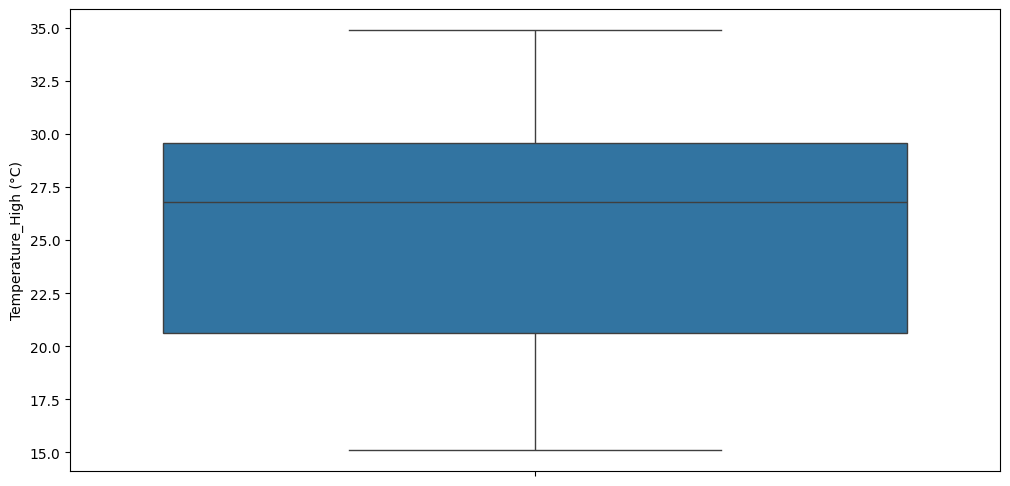

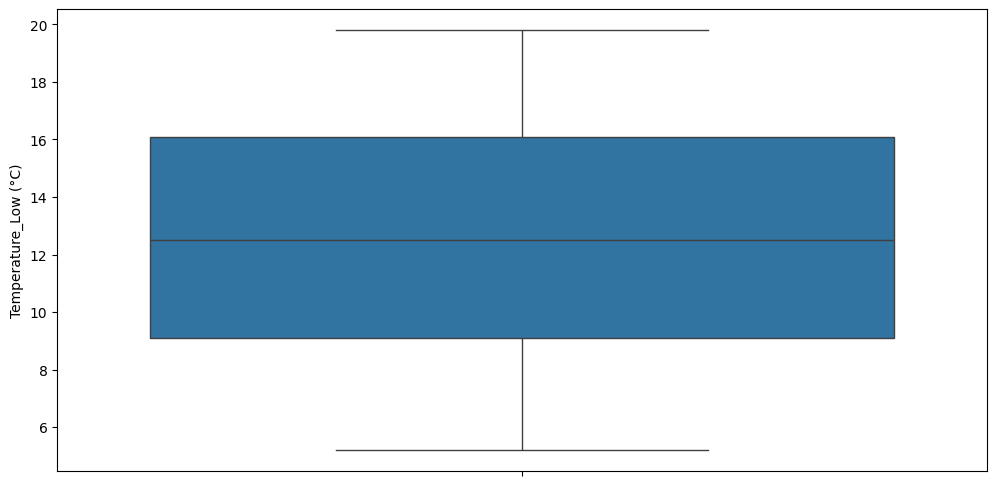

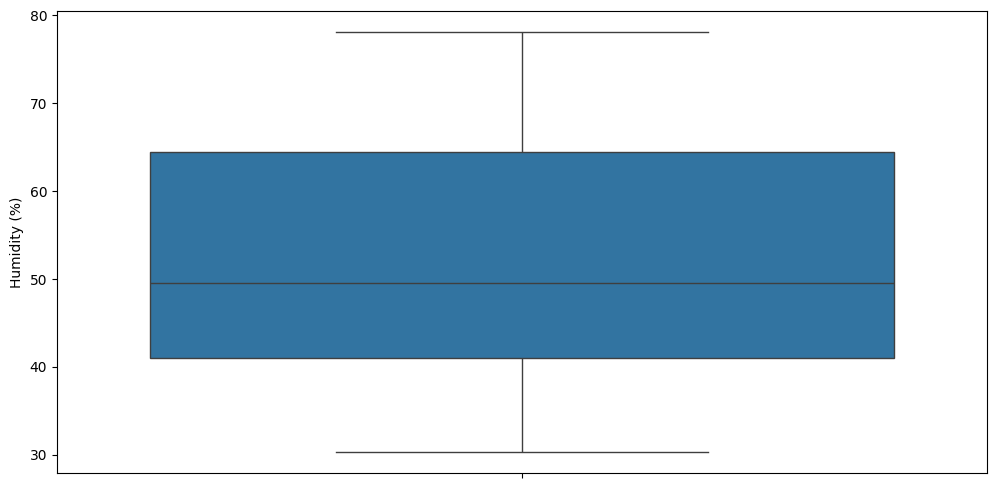

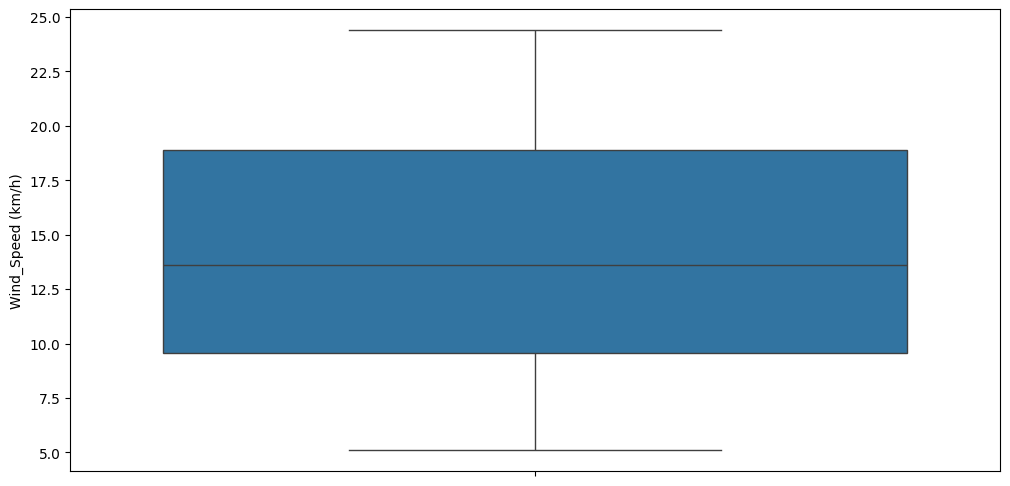

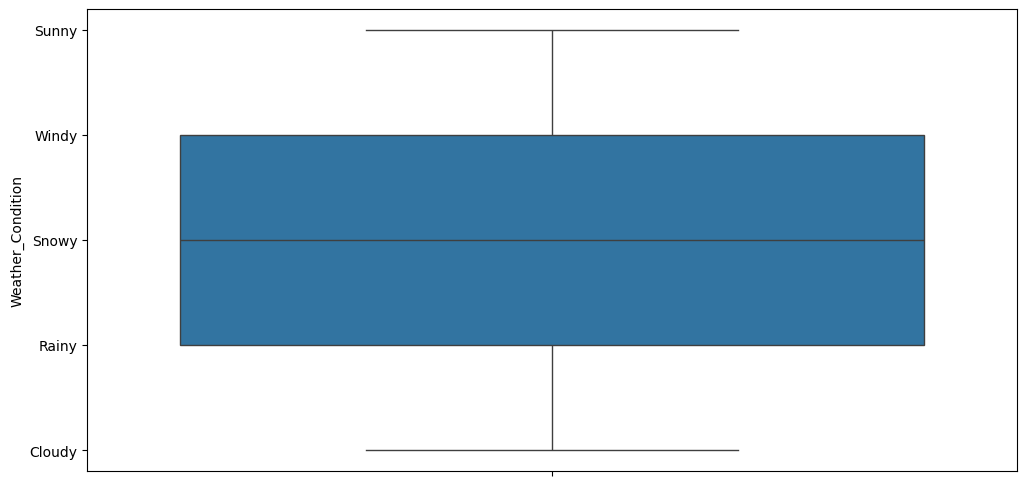

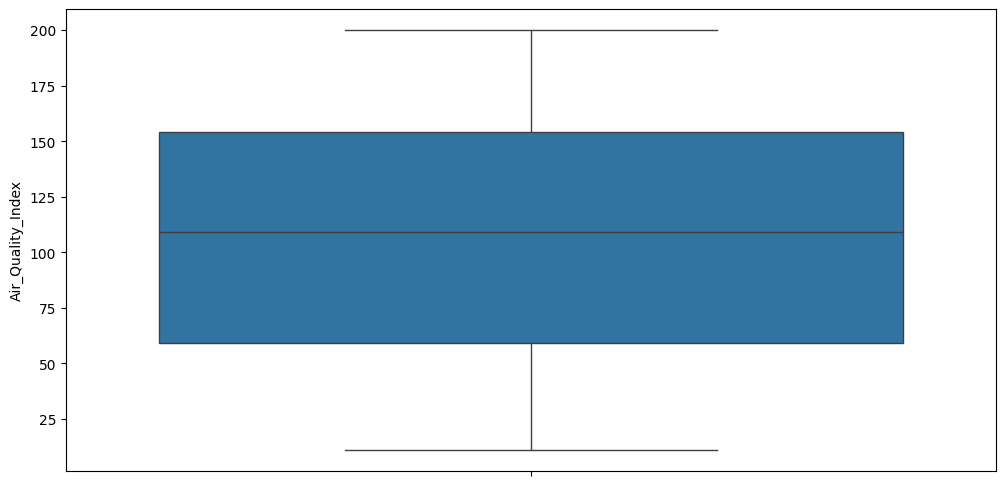

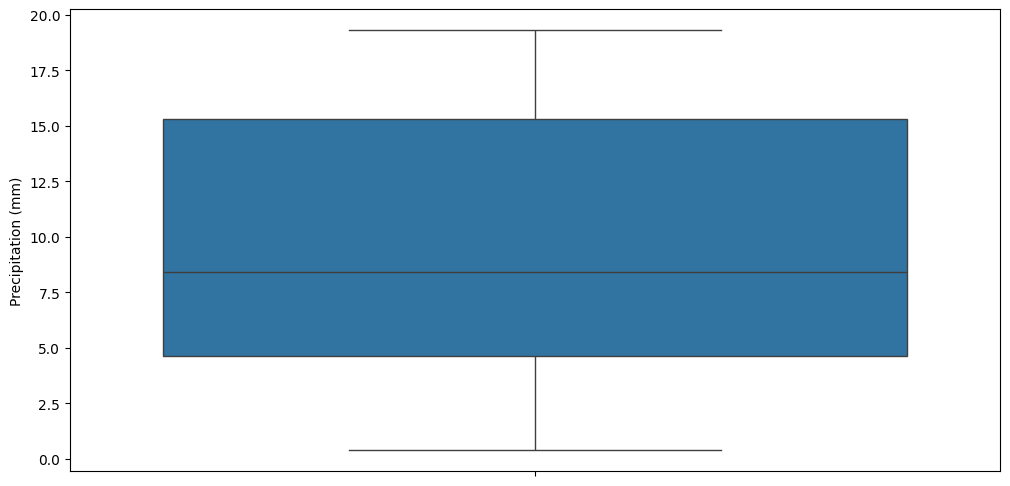

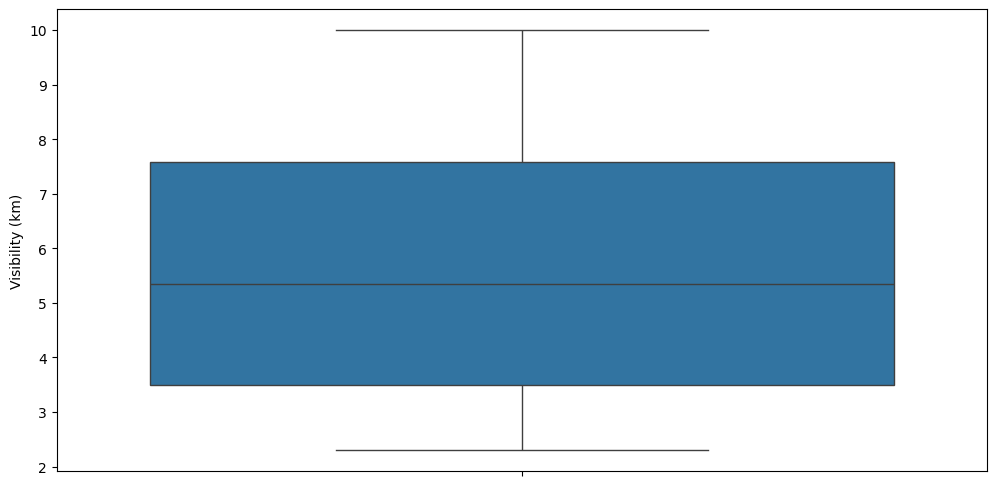

In [245]:
for i in weather.columns:
  plt.figure(figsize=(12,6))
  sns.boxplot(weather[i])
  plt.show()

In [246]:
df = df.merge(weather, left_index=True, right_index=True, how='left')

In [247]:
print(df.head(5))

             sales  lag_7  lag_30  rolling_7  rolling_14  day_of_week  month  \
date                                                                           
2025-01-01  281.64    NaN     NaN        NaN         NaN            2      1   
2025-01-02  212.74    NaN     NaN        NaN         NaN            3      1   
2025-01-03  250.61    NaN     NaN        NaN         NaN            4      1   
2025-01-04  253.38    NaN     NaN        NaN         NaN            5      1   
2025-01-05  253.00    NaN     NaN        NaN         NaN            6      1   

            is_weekend   City  Temperature_High (°C)  Temperature_Low (°C)  \
date                                                                         
2025-01-01           0  Cairo                   16.9                  14.1   
2025-01-02           0  Cairo                   15.1                   5.6   
2025-01-03           0  Cairo                   25.1                  18.2   
2025-01-04           1  Cairo                   2

In [248]:
from sklearn.preprocessing import LabelEncoder

In [249]:
le=LabelEncoder()

In [250]:
for i in weather.columns:
  if weather[i].dtype=='object':
    weather[i]=le.fit_transform(weather[i])

In [251]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   90 non-null     int64  
 1   Temperature_High (°C)  90 non-null     float64
 2   Temperature_Low (°C)   90 non-null     float64
 3   Humidity (%)           90 non-null     float64
 4   Wind_Speed (km/h)      90 non-null     float64
 5   Weather_Condition      90 non-null     int64  
 6   Air_Quality_Index      90 non-null     int64  
 7   Precipitation (mm)     90 non-null     float64
 8   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(3)
memory usage: 7.0 KB


In [252]:
weather.isnull().sum()

,0
City,0
Temperature_High (°C),0
Temperature_Low (°C),0
Humidity (%),0
Wind_Speed (km/h),0
Weather_Condition,0
Air_Quality_Index,0
Precipitation (mm),0
Visibility (km),0


In [253]:
weather.duplicated().sum()

0

Features

In [254]:
weather['avg_temp'] = (weather['Temperature_High (°C)'] + weather['Temperature_Low (°C)']) / 2

# Ensure weather index is unique before assigning to df
# This handles the duplicates introduced by the merge with 'events'
# We keep the first occurrence as the weather values (temp, precip) should be identical for duplicate dates
weather_deduplicated = weather.loc[~weather.index.duplicated(keep='first')].copy()

df['temperature'] = weather_deduplicated['avg_temp']
df['rainfall'] = weather_deduplicated['Precipitation (mm)']

In [255]:
print(weather['avg_temp'])

Date
2025-01-01    15.50
2025-01-02    10.35
2025-01-03    21.65
2025-01-04    19.40
2025-01-05    15.65
              ...  
2025-03-27    21.25
2025-03-28    16.75
2025-03-29    19.80
2025-03-30    23.40
2025-03-31    16.05
Name: avg_temp, Length: 90, dtype: float64


In [256]:
# Event calendar
events = pd.read_csv("/content/Global_Holidays_2025_2035.csv")



In [257]:
print(events.head(5))

  Country  Year        Date               Holiday_Name  Local_Name  \
0      IN  2025  2025-01-01             New Year's Day         NaN   
1      IN  2025  2025-01-02       Last day of Hanukkah         NaN   
2      IN  2025  2025-01-06  Guru Govind Singh Jayanti         NaN   
3      IN  2025  2025-01-13                      Lohri         NaN   
4      IN  2025  2025-01-14                     Pongal         NaN   

                         Type  \
0            Optional holiday   
1                  Observance   
2            Optional holiday   
3                  Observance   
4  Hinduism, Optional holiday   

                                         Description  
0  New Year’s Day is celebrated many countries su...  
1  Hanukkah, also known as Chanukah or the Festiv...  
2  Guru Gobind Singh Jayanti is the Sikh annual c...  
3                     Lohri is a observance in India  
4  Many southern states in India, particularly Ta...  


In [258]:
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10540 entries, 0 to 10539
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       10540 non-null  object 
 1   Year          10540 non-null  int64  
 2   Date          10540 non-null  object 
 3   Holiday_Name  10540 non-null  object 
 4   Local_Name    0 non-null      float64
 5   Type          10540 non-null  object 
 6   Description   10485 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 576.5+ KB
None


In [259]:
print(events.describe())

               Year  Local_Name
count  10540.000000         0.0
mean    2029.971063         NaN
std        3.167677         NaN
min     2025.000000         NaN
25%     2027.000000         NaN
50%     2030.000000         NaN
75%     2033.000000         NaN
max     2035.000000         NaN


In [260]:
print(events.isnull().sum())

Country             0
Year                0
Date                0
Holiday_Name        0
Local_Name      10540
Type                0
Description        55
dtype: int64


In [261]:
events.Local_Name.unique()

array([nan])

In [262]:
events.drop(columns='Local_Name', inplace=True, errors='ignore')

In [263]:
events.drop(columns='Description', inplace=True, errors='ignore')

In [264]:
events.isnull().sum()

,0
Country,0
Year,0
Date,0
Holiday_Name,0
Type,0


In [265]:
print(events.duplicated().sum())

0


In [266]:
events.drop_duplicates(inplace=True)

In [267]:
events['Date'] = pd.to_datetime(events['Date'], format='%Y-%m-%d', errors='coerce')

In [268]:
events.set_index('Date',inplace=True)

In [269]:
events.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10540 entries, 2025-01-01 to 2035-12-31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       10540 non-null  object
 1   Year          10540 non-null  int64 
 2   Holiday_Name  10540 non-null  object
 3   Type          10540 non-null  object
dtypes: int64(1), object(3)
memory usage: 411.7+ KB


In [270]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
for i in events.columns:
  if events[i].dtype=='object':
    events[i]=le1.fit_transform(events[i])

In [271]:
events.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10540 entries, 2025-01-01 to 2035-12-31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Country       10540 non-null  int64
 1   Year          10540 non-null  int64
 2   Holiday_Name  10540 non-null  int64
 3   Type          10540 non-null  int64
dtypes: int64(4)
memory usage: 411.7 KB


In [272]:
events['Year'] = pd.to_datetime(events['Year'], format='%Y')

In [273]:
df = df.merge(events, left_index=True, right_index=True, how='left')

In [274]:
events['is_holiday']=events['Holiday_Name'].notnull().astype(int)
events['is_eventday']=events['Type'].notnull().astype(int)

In [275]:
df.isnull().sum()

,0
sales,0
lag_7,26
lag_30,78
rolling_7,20
rolling_14,33
day_of_week,0
month,0
is_weekend,0
City,796
Temperature_High (°C),796


In [290]:
# Identify numeric columns to fill with 0
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Datetime columns should ideally be left with NaT or handled specifically if a fill value is truly needed
# For now, we'll leave datetime NaNs as NaT as filling with 0 is inappropriate.
# df['Year'] = df['Year'].fillna(pd.NaT) # If you explicitly wanted to fill, this is the way


In [291]:
df.isnull().sum().sum()

0

In [292]:
df.shape

(1046, 23)

In [293]:
print(df)

             sales   lag_7  lag_30   rolling_7  rolling_14  day_of_week  \
date                                                                      
2025-01-01  281.64    0.00    0.00    0.000000    0.000000            2   
2025-01-01  281.64    0.00    0.00    0.000000    0.000000            2   
2025-01-01  281.64    0.00    0.00    0.000000    0.000000            2   
2025-01-01  281.64    0.00    0.00    0.000000    0.000000            2   
2025-01-01  281.64    0.00    0.00    0.000000    0.000000            2   
...            ...     ...     ...         ...         ...          ...   
2025-12-31  240.18  251.66  227.51  301.624286  288.697857            2   
2025-12-31  240.18  251.66  227.51  301.624286  288.697857            2   
2025-12-31  240.18  251.66  227.51  301.624286  288.697857            2   
2025-12-31  240.18  251.66  227.51  301.624286  288.697857            2   
2025-12-31  240.18  251.66  227.51  301.624286  288.697857            2   

            month  is_we

model building

In [294]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor


In [295]:
# Prepare features
features = ['lag_7','lag_30','rolling_7','rolling_14','day_of_week','month','is_weekend']
X = df[features].dropna()
y = df['sales'].loc[X.index]

In [298]:
print(features)

['lag_7', 'lag_30', 'rolling_7', 'rolling_14', 'day_of_week', 'month', 'is_weekend']


In [299]:
print(X)

             lag_7  lag_30   rolling_7  rolling_14  day_of_week  month  \
date                                                                     
2025-01-01    0.00    0.00    0.000000    0.000000            2      1   
2025-01-01    0.00    0.00    0.000000    0.000000            2      1   
2025-01-01    0.00    0.00    0.000000    0.000000            2      1   
2025-01-01    0.00    0.00    0.000000    0.000000            2      1   
2025-01-01    0.00    0.00    0.000000    0.000000            2      1   
...            ...     ...         ...         ...          ...    ...   
2025-12-31  251.66  227.51  301.624286  288.697857            2     12   
2025-12-31  251.66  227.51  301.624286  288.697857            2     12   
2025-12-31  251.66  227.51  301.624286  288.697857            2     12   
2025-12-31  251.66  227.51  301.624286  288.697857            2     12   
2025-12-31  251.66  227.51  301.624286  288.697857            2     12   

            is_weekend  
date        

In [300]:
print(y)

date
2025-01-01    281.64
2025-01-01    281.64
2025-01-01    281.64
2025-01-01    281.64
2025-01-01    281.64
               ...  
2025-12-31    240.18
2025-12-31    240.18
2025-12-31    240.18
2025-12-31    240.18
2025-12-31    240.18
Name: sales, Length: 6078, dtype: float64


In [296]:
# Train-test split (time-based)
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [297]:
# Baseline model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [301]:
# Advanced model
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)